#### Fig. 5 b, c, d, e, f, g, Supp. Fig 7 a

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 14,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 14,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [8]:
h5ad_savedir = "h5ad"
os.makedirs(h5ad_savedir, exist_ok=True)

In [9]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [10]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

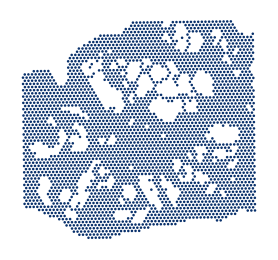

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc

fig, ax = plt.subplots(1,1, figsize = (3,3))

# Plot the large spatial image
sc.pl.spatial(
    adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :],
    library_id="20_41615_B1",
    #alpha_img=0,
    img_key = None,
    #palette = color_dict,
    size=1,
    ax=ax,
    color="in_tissue",
    vmin='p10',
    vmax='p99',
    color_map = "Blues_r",
    colorbar_loc=None,
    show=False
)




ax.set_xlabel("")
ax.set_ylabel("")
#ax_big.set_ylim(2000,0)
#ax_big.set_xlim(0,2000)
ax.set_title("")
#ax.get_legend().remove()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(w_pad=0, h_pad=1)
plt.savefig(os.path.join(save_dir,"tissue_spots_example.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


In [ ]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [ ]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41847_A1': 'UNC #1',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_05738_A1': 'UNC #2',
 '21_57231_A3': 'CHP #1',
 '21_25528_A3': 'UNC #3',
 '22_18446_A1': 'UNC #4',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '22_50637_A1': 'UNC #5',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '24_10794_B1': 'UNC #7',
 '20_12743_C1': 'UNC #8',
 '21_55244_B1': 'UNC #9',
 '23_45450_A3': 'UNC #10',
 '24_23755_A1': 'UNC #11',
 '16_53837_A10': 'UNC #12',
 '19_48719_A1': 'UNC #13',
 '17_35291_B1': 'UNC #14',
 '16_46257_A1': 'UNC #15',
 '18_23779_A2': 'UNC #16',
 '12_39986_A2': 'UNC #17',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP 

In [239]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [12]:
fts = adata_vis.obs["factor_assigned"].unique().tolist()

In [13]:
fts

['B',
 'ATI/Endo',
 'Macro',
 'SMC',
 'Alv. FB/immune',
 'Plasma',
 'Perib. FB',
 'Adv. FB',
 'Immune',
 'Alv. macro',
 'Airway',
 'ATII']

In [14]:
from itertools import combinations

In [15]:
from scipy.stats import skew, kurtosis

In [16]:
import seaborn as sns
print(sns.color_palette("deep").as_hex())


['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']


In [17]:
nmf_columns = [f"{ft}_log_minmax" for ft in fts]

In [18]:
nmf_columns

['B_log_minmax',
 'ATI/Endo_log_minmax',
 'Macro_log_minmax',
 'SMC_log_minmax',
 'Alv. FB/immune_log_minmax',
 'Plasma_log_minmax',
 'Perib. FB_log_minmax',
 'Adv. FB_log_minmax',
 'Immune_log_minmax',
 'Alv. macro_log_minmax',
 'Airway_log_minmax',
 'ATII_log_minmax']

In [20]:
adata_vis.obs[nmf_columns].values

array([[0.77308363, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.83760568, 0.        , ..., 0.56946104, 0.71857101,
        0.        ],
       [0.        , 0.831651  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.75050454, 0.71933608, ..., 0.        , 0.        ,
        0.70722412],
       [0.        , 0.75952223, 0.49478757, ..., 0.46909938, 0.29187375,
        0.82589076],
       [0.        , 0.88669098, 0.        , ..., 0.        , 0.43519281,
        0.        ]])

In [ ]:
libraries = adata_vis.obs['library_id'].unique()
all_interface_summaries = []

for lib in libraries:
    adata_lib = adata_vis[adata_vis.obs['library_id'] == lib].copy()
    condition = adata_lib.obs['cond'].unique()[0]
    
    # Row indices for this library within adata_vis
    lib_indices = adata_vis.obs['library_id'] == lib
    
    # Do everything from here per library 

    # Using log_minmax normalized values
    # Columns are niches; rows are spots
    nmf_matrix = adata_lib.obs[nmf_columns].values
    #nmf_matrix_normalized = nmf_matrix / np.sum(nmf_matrix, axis=1, keepdims=True)

    # Remove the suffix to get raw niche names
    key_names = [item.replace("_log_minmax","") for item in nmf_columns]

    # Now compute pairwise interface scores based on normalized values
    # range(0,12)
    # Get all pairs of numbers between 0 and 11 (these are indices)
    for i, j in combinations(range(nmf_matrix.shape[1]), 2):
        # Combine two raw niche names together separated by __
        key = f'{key_names[i]}__{key_names[j]}'
        #### KEY CALCULATION
        score = np.minimum(nmf_matrix[:, i], nmf_matrix[:, j])


        # Assign scores only to the matching rows in adata_vis.obs
        # ex. creates new columns like "B__Plasma"
        # spot-wise score for all pairwise combinations of niches
        adata_vis.obs.loc[lib_indices, key] = score
        
        # Compute summary stats for each pair
        # Summarize distribution
        mean_score = np.mean(score)
        std_score = np.std(score)
        median_score = np.median(score)
        skew_score = skew(score)
        kurt_score = kurtosis(score)
        zero_fraction = np.sum(score == 0) / len(score)

        all_interface_summaries.append({
            'library_id': lib,
            'condition': condition,
            'interface': key,
            'mean_score': mean_score,
            'std_score': std_score,
            'median_score': median_score,
            'skewness': skew_score,
            'kurtosis': kurt_score,
            'zero_fraction': zero_fraction
        })




In [88]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [103]:
from matplotlib.patches import Rectangle


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


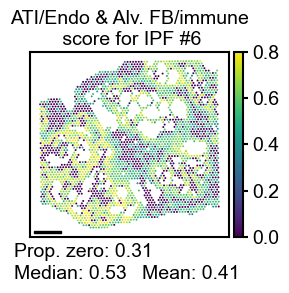

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (3.2, 2.8))


# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["20_41615_B1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar 

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.02),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax.transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Plot the large spatial image
sc.pl.spatial(
    adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :],
    library_id="20_41615_B1",
    #alpha_img=0,
    img_key = None,
    #palette = color_dict,
    size=1,
    ax=ax,
    color="ATI/Endo__Alv. FB/immune",
    vmin='0.0',
    vmax='0.8',
    color_map = "viridis",
    colorbar_loc=None,
    show=False
)

ax.add_patch(scale_bar)


ax.set_xlabel("")
ax.set_ylabel("")
#ax_big.set_ylim(2000,0)
#ax_big.set_xlim(0,2000)
ax.set_title(f"ATI/Endo & Alv. FB/immune\n score for {adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :].obs['lay_id'].unique()[0]}", pad = 5, fontsize = 14)
#ax.get_legend().remove()

# for spine in ax.spines.values():
#     spine.set_visible(False)



plt.colorbar(
    ax.collections[0],
    ax=ax,
    fraction=0.05,   # changes width
    pad=0.02
)

# Calculate score summaries
subset = adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :]

score = subset.obs["ATI/Endo__Alv. FB/immune"]


fig.text(0.1, 0.03, f"Prop. zero: {(np.sum(score == 0) / len(score)):.2f}", ha='left', va='bottom',
         fontsize=14)
fig.text(0.1, -0.05, f"Median: {np.median(score):.2f}", ha='left', va='bottom',
         fontsize=14)
fig.text(0.5, -0.05, f"Mean: {np.mean(score):.2f}", ha='left', va='bottom',
         fontsize=14)

plt.tight_layout(w_pad=0, h_pad=1)
plt.savefig(os.path.join(save_dir,"min_score_example_high.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


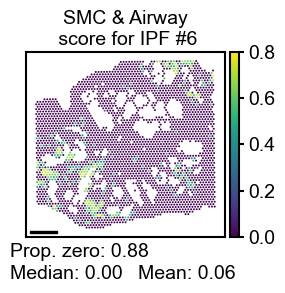

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (3.2, 2.8))


# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["20_41615_B1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar 

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.02),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax.transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Plot the large spatial image
sc.pl.spatial(
    adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :],
    library_id="20_41615_B1",
    #alpha_img=0,
    img_key = None,
    #palette = color_dict,
    size=1,
    ax=ax,
    color="SMC__Airway",
    vmin='0.0',
    vmax='0.8',
    color_map = "viridis",
    colorbar_loc=None,
    show=False
)

ax.add_patch(scale_bar)


ax.set_xlabel("")
ax.set_ylabel("")
#ax_big.set_ylim(2000,0)
#ax_big.set_xlim(0,2000)
ax.set_title(f"SMC & Airway\n score for {adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :].obs['lay_id'].unique()[0]}", pad = 5, fontsize = 14)
#ax.get_legend().remove()

# for spine in ax.spines.values():
#     spine.set_visible(False)



plt.colorbar(
    ax.collections[0],
    ax=ax,
    fraction=0.05,   # changes width
    pad=0.02
)

# Calculate score summaries
subset = adata_vis[adata_vis.obs["library_id"] == "20_41615_B1", :]

score = subset.obs["SMC__Airway"]


fig.text(0.1, 0.03, f"Prop. zero: {(np.sum(score == 0) / len(score)):.2f}", ha='left', va='bottom',
         fontsize=14)
fig.text(0.1, -0.05, f"Median: {np.median(score):.2f}", ha='left', va='bottom',
         fontsize=14)
fig.text(0.5, -0.05, f"Mean: {np.mean(score):.2f}", ha='left', va='bottom',
         fontsize=14)


plt.tight_layout(w_pad=0, h_pad=1)
plt.savefig(os.path.join(save_dir,"min_score_example_low.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


In [24]:
all_interface_summaries

[{'library_id': '18_57617_A1',
  'condition': 'IPF',
  'interface': 'B__ATI/Endo',
  'mean_score': 0.04805463025181289,
  'std_score': 0.13654149611929775,
  'median_score': 0.0,
  'skewness': 2.702400012247438,
  'kurtosis': 5.941278354227286,
  'zero_fraction': 0.8805067664843075},
 {'library_id': '18_57617_A1',
  'condition': 'IPF',
  'interface': 'B__Macro',
  'mean_score': 0.025047808820779137,
  'std_score': 0.11011092911184892,
  'median_score': 0.0,
  'skewness': 4.5019214403894035,
  'kurtosis': 19.493201855102946,
  'zero_fraction': 0.9450043190325367},
 {'library_id': '18_57617_A1',
  'condition': 'IPF',
  'interface': 'B__SMC',
  'mean_score': 0.035610675126195,
  'std_score': 0.1224597109862585,
  'median_score': 0.0,
  'skewness': 3.4407895967070545,
  'kurtosis': 10.82374798423188,
  'zero_fraction': 0.9141952202706594},
 {'library_id': '18_57617_A1',
  'condition': 'IPF',
  'interface': 'B__Alv. FB/immune',
  'mean_score': 0.060520196813546485,
  'std_score': 0.16488250

In [25]:
# Convert to DataFrame
interface_df = pd.DataFrame(all_interface_summaries)

In [26]:
interface_df

,library_id,condition,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
0,18_57617_A1,IPF,B__ATI/Endo,0.048055,0.136541,0.0,2.702400,5.941278,0.880507
1,18_57617_A1,IPF,B__Macro,0.025048,0.110111,0.0,4.501921,19.493202,0.945004
2,18_57617_A1,IPF,B__SMC,0.035611,0.122460,0.0,3.440790,10.823748,0.914195
3,18_57617_A1,IPF,B__Alv. FB/immune,0.060520,0.164883,0.0,2.616672,5.534464,0.868701
4,18_57617_A1,IPF,B__Plasma,0.040311,0.138604,0.0,3.416016,10.529263,0.914195
...,...,...,...,...,...,...,...,...,...
2899,22_16220_B1,IPF,Immune__Airway,0.110075,0.208924,0.0,1.489934,0.464101,0.770247
2900,22_16220_B1,IPF,Immune__ATII,0.271042,0.298076,0.0,0.314137,-1.700917,0.524852
2901,22_16220_B1,IPF,Alv. macro__Airway,0.054631,0.159476,0.0,2.761097,6.138303,0.887035
2902,22_16220_B1,IPF,Alv. macro__ATII,0.189138,0.286408,0.0,0.970051,-0.857297,0.679875


In [27]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned,B__ATI/Endo,B__Macro,B__SMC,B__Alv. FB/immune,B__Plasma,B__Perib. FB,B__Adv. FB,B__Immune,B__Alv. macro,B__Airway,B__ATII,ATI/Endo__Macro,ATI/Endo__SMC,ATI/Endo__Alv. FB/immune,ATI/Endo__Plasma,ATI/Endo__Perib. FB,ATI/Endo__Adv. FB,ATI/Endo__Immune,ATI/Endo__Alv. macro,ATI/Endo__Airway,ATI/Endo__ATII,Macro__SMC,Macro__Alv. FB/immune,Macro__Plasma,Macro__Perib. FB,Macro__Adv. FB,Macro__Immune,Macro__Alv. macro,Macro__Airway,Macro__ATII,SMC__Alv. FB/immune,SMC__Plasma,SMC__Perib. FB,SMC__Adv. FB,SMC__Immune,SMC__Alv. macro,SMC__Airway,SMC__ATII,Alv. FB/immune__Plasma,Alv. FB/immune__Perib. FB,Alv. FB/immune__Adv. FB,Alv. FB/immune__Immune,Alv. FB/immune__Alv. macro,Alv. FB/immune__Airway,Alv. FB/immune__ATII,Plasma__Perib. FB,Plasma__Adv. FB,Plasma__Immune,Plasma__Alv. macro,Plasma__Airway,Plasma__ATII,Perib. FB__Adv. FB,Perib. FB__Immune,Perib. FB__Alv. macro,Perib. FB__Airway,Perib. FB__ATII,Adv. FB__Immune,Adv. FB__Alv. macro,Adv. FB__Airway,Adv. FB__ATII,Immune__Alv. macro,Immune__Airway,Immune__ATII,Alv. macro__Airway,Alv. macro__ATII,Airway__ATII
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,

In [28]:
interface_df[interface_df['condition']=="IPF"].sort_values(by='zero_fraction', ascending=True)['interface']

767       Alv. FB/immune__Immune
743             ATI/Endo__Immune
739     ATI/Endo__Alv. FB/immune
475     ATI/Endo__Alv. FB/immune
2719    ATI/Endo__Alv. FB/immune
                  ...           
2729               Macro__Plasma
2707                    B__Macro
140                B__Alv. macro
661                     B__Macro
668                B__Alv. macro
Name: interface, Length: 660, dtype: object

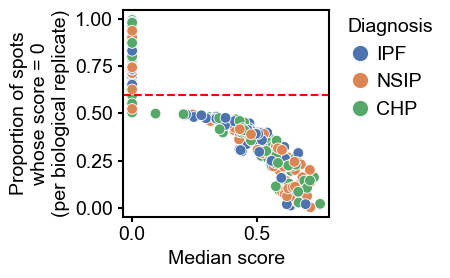

In [317]:
import seaborn as sns

cond_labels = ["IPF", "NSIP", "CHP"]
cond_colors = sns.color_palette("deep", n_colors=3)

# Scatter plot: std_score vs. mean_score (or any other columns)
fig, ax = plt.subplots(figsize=(4, 3))  # Can be any shape now
sns.scatterplot(data=interface_df[interface_df['condition']!="UNC"].sample(frac =1 ,random_state=42), x='median_score', y='zero_fraction', hue='condition',
                palette=dict(zip(cond_labels, cond_colors)), ax = ax, s= 60)



plt.xlabel('Median score')
plt.ylabel('Proportion of spots\nwhose score = 0\n(per biological replicate)')
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)
ax.set_box_aspect(1)



plt.tight_layout()
plt.savefig(os.path.join(save_dir,"zero_fraction_v_median_score_by_cond.pdf"), bbox_inches='tight', transparent = True)
plt.show()

In [269]:
print(cond_colors.as_hex())

['#4c72b0', '#dd8452', '#55a868']


112

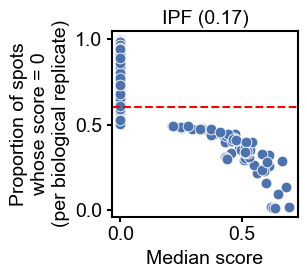

In [318]:
cond_labels = ["IPF", "NSIP", "CHP"]
cond_colors = sns.color_palette("deep", n_colors=3)

# Scatter plot: std_score vs. mean_score (or any other columns)
fig, ax = plt.subplots(figsize=(4, 3))  # Can be any shape now
sns.scatterplot(data=interface_df[interface_df['condition']== "IPF"], x='median_score', y='zero_fraction', #hue='library_id',
                #palette=dict(zip(cond_labels, cond_colors)), 
                color = '#4c72b0',
                ax = ax, s= 60)



plt.xlabel('Median score')
plt.ylabel('Proportion of spots\nwhose score = 0\n(per biological replicate)')
plt.title(f'IPF ({(interface_df[interface_df['condition']== "IPF"]['zero_fraction'] <= 0.6).sum()/(interface_df[interface_df['condition']== "IPF"].shape[0]):.2f})',pad = 5, fontsize =14)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)
ax.set_box_aspect(1)

# plt.text(0.02, 0.02,
#          f"{(interface_df[interface_df['condition']== "IPF"]['zero_fraction'] <= 0.6).sum()}",
#          fontsize = 14,
#          color = 'black')

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"zero_fraction_v_median_score_IPF.pdf"), bbox_inches='tight', transparent = True)
plt.show()

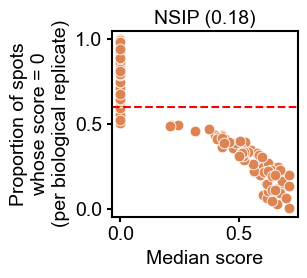

In [319]:
cond_labels = ["IPF", "NSIP", "CHP"]
cond_colors = sns.color_palette("deep", n_colors=3)

# Scatter plot: std_score vs. mean_score (or any other columns)
fig, ax = plt.subplots(figsize=(4, 3))  # Can be any shape now
sns.scatterplot(data=interface_df[interface_df['condition']== "NSIP"], x='median_score', y='zero_fraction', #hue='condition',
                #palette=dict(zip(cond_labels, cond_colors)),
                color = "#dd8452",
                ax = ax, s= 60)



plt.xlabel('Median score')
plt.ylabel('Proportion of spots\nwhose score = 0\n(per biological replicate)')
plt.title(f'NSIP ({(interface_df[interface_df['condition']== "NSIP"]['zero_fraction'] <= 0.6).sum()/(interface_df[interface_df['condition']== "NSIP"].shape[0]):.2f})',pad = 5, fontsize =14)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)
ax.set_box_aspect(1)



plt.tight_layout()
plt.savefig(os.path.join(save_dir,"zero_fraction_v_median_score_NSIP.pdf"), bbox_inches='tight', transparent = True)
plt.show()

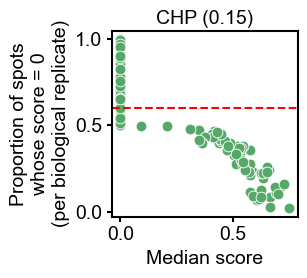

In [320]:
cond_labels = ["IPF", "NSIP", "CHP"]
cond_colors = sns.color_palette("deep", n_colors=3)

# Scatter plot: std_score vs. mean_score (or any other columns)
fig, ax = plt.subplots(figsize=(4, 3))  # Can be any shape now
sns.scatterplot(data=interface_df[interface_df['condition']== "CHP"], x='median_score', y='zero_fraction', #hue='condition',
                #palette=dict(zip(cond_labels, cond_colors)), 
                color = '#55a868',
                ax = ax, s= 60)



plt.xlabel('Median score')
plt.ylabel('Proportion of spots\nwhose score = 0\n(per biological replicate)')
plt.title(f'CHP ({(interface_df[interface_df['condition']== "CHP"]['zero_fraction'] <= 0.6).sum()/(interface_df[interface_df['condition']== "CHP"].shape[0]):.2f})',pad = 5, fontsize =14)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)
ax.set_box_aspect(1)



plt.tight_layout()
plt.savefig(os.path.join(save_dir,"zero_fraction_v_median_score_CHP.pdf"), bbox_inches='tight', transparent = True)
plt.show()

In [30]:
# Which interfaces are the most common across samples per condition?
top_interfaces_concat = pd.concat(
    [interface_df[interface_df['condition']=="IPF"][
    interface_df[interface_df['condition']=="IPF"]['zero_fraction'] <= 0.60]['interface'].value_counts()/10,
    interface_df[interface_df['condition']=="NSIP"][
    interface_df[interface_df['condition']=="NSIP"]['zero_fraction'] <= 0.60]['interface'].value_counts()/8,
    interface_df[interface_df['condition']=="CHP"][
    interface_df[interface_df['condition']=="CHP"]['zero_fraction'] <= 0.60]['interface'].value_counts()/10,
    ], axis=1, keys=['IPF','NSIP','CHP']
)


In [31]:
top_interfaces_concat

,IPF,NSIP,CHP
interface,,,
ATI/Endo__Alv. FB/immune,1.0,1.000,1.0
ATI/Endo__SMC,0.9,0.250,0.7
Alv. FB/immune__Immune,0.9,0.750,0.9
ATI/Endo__Immune,0.9,0.750,0.9
SMC__Alv. FB/immune,0.9,0.250,0.6
ATI/Endo__ATII,0.8,0.750,0.9
Alv. FB/immune__ATII,0.6,0.750,0.8
ATI/Endo__Perib. FB,0.6,0.375,0.1
SMC__Immune,0.6,NaN,0.3


In [32]:
top_interfaces_concat_filled = top_interfaces_concat.fillna(0)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/1869116102.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


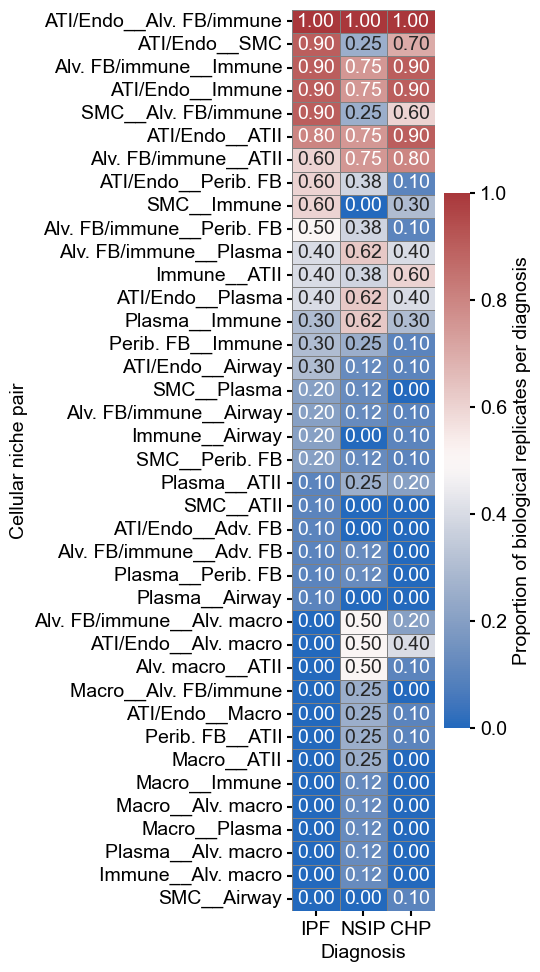

In [ ]:

fig, ax = plt.subplots(1,1,figsize=(2.3, 0.3 * len(top_interfaces_concat_filled)))  # adjust size as needed
sns.heatmap(
    top_interfaces_concat_filled,
    cmap="vlag",    
    vmin=0, vmax=1,    
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Proportion of biological replicates per diagnosis"},
    ax = ax,
    annot=True,
    fmt = ".2f",
    annot_kws={"size":14}
    
)
plt.xlabel("Diagnosis")
plt.ylabel("Cellular niche pair")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_top_interfaces_concat_log_minmax.pdf"), bbox_inches='tight', transparent = True)
plt.savefig(os.path.join(save_dir,"hm_top_interfaces_concat_log_minmax.png"), bbox_inches='tight', pad_inches=0.2, dpi = 1200, transparent = True)

plt.show()


In [415]:
filtered_df['lay_id']

13       IPF #1
2719     IPF #8
2785     IPF #9
739      IPF #7
673      IPF #6
475      IPF #5
2851    IPF #10
343      IPF #4
79       IPF #2
145      IPF #3
2323    NSIP #8
2257    NSIP #7
409     NSIP #3
2125    NSIP #5
2191    NSIP #6
211     NSIP #1
277     NSIP #2
541     NSIP #4
1333     CHP #5
1069     CHP #2
871      CHP #1
2389     CHP #6
2455     CHP #7
2521     CHP #8
2587     CHP #9
2653    CHP #10
1267     CHP #4
1135     CHP #3
Name: lay_id, dtype: object

In [455]:
import matplotlib.patches as mpatches

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2636347698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2636347698.py:30: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2636347698.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([x.split('#')[-1] for x in lay_order], rotation=90, fontsize=8)
/var/folders/65/h4__q7c96m5bzl

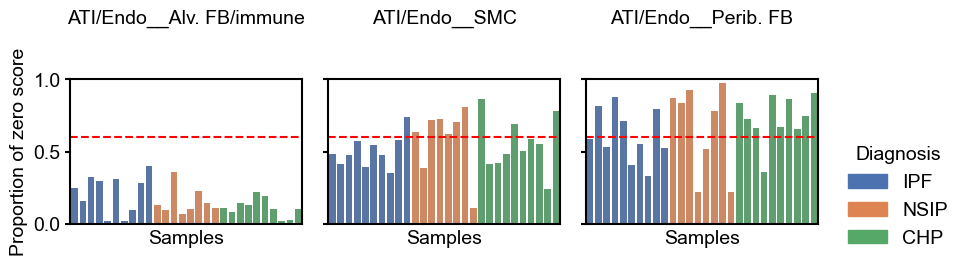

In [ ]:
target_interface = ['ATI/Endo__Alv. FB/immune', 'ATI/Endo__SMC', 'ATI/Endo__Perib. FB']


fig, ax = plt.subplots(1,3, figsize = (8.5,2.8), sharey = True)

for i, interface in enumerate(target_interface): 

    # Filter for the specific interface
    filtered_df = interface_df[(interface_df['interface'] == interface) & (interface_df['condition']!="UNC")]

    # Ensure cond is categorical with the desired order
    cond_order = ['IPF','NSIP','CHP']
    filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)

    # Sort the dataframe by cond to ensure correct order of bars
    filtered_df = filtered_df.sort_values('condition')

    filtered_df['lay_id'] = filtered_df['library_id'].map(key_map)
    filtered_df['replicate'] = filtered_df['lay_id'].str.split('#').str[1].astype(int)
    filtered_df['condition_order'] = filtered_df['condition'].apply(lambda x: ['IPF','NSIP','CHP'].index(x))

    # Sort by condition_order, then replicate
    filtered_df = filtered_df.sort_values(['condition_order', 'replicate'])

    # Create ordered list of lay_ids for the x-axis
    lay_order = filtered_df['lay_id'].tolist()

    # Create the barplot
    sns.barplot(
        data=filtered_df,
        x='lay_id',
        y='zero_fraction',
        hue='condition',
        dodge=False,
        palette=sns.color_palette("deep"),
        ax = ax[i], legend = False, 
        order = lay_order
    )

    # Horizontal line
    ax[i].axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

    # Clean x-tick labels: only replicate number
    ax[i].set_xticklabels([x.split('#')[-1] for x in lay_order], rotation=90, fontsize=8)
    
    # Subplot title
    ax[i].set_title(interface, pad=40)
    ax[i].set_xticks([])
          

# Only first axis gets y-label
ax[0].set_ylabel("Proportion of zero score")
# Set x-labels
for ax in ax:
    ax.set_xlabel("Samples")

plt.ylim(0, 1)
plt.tight_layout()

plt.ylim(0,1)


# --- Add a single shared legend ---
fig.legend(
    [mpatches.Patch(color=color, label=label) for color, label in zip(sns.color_palette("deep")[:3], ['IPF','NSIP','CHP'])],
    ['IPF','NSIP','CHP'],
    title="Diagnosis",
    loc='upper left',   
    ncol=1,               # horizontal layout
    frameon=False,
    bbox_to_anchor=(0.99, 0.5)  # adjust position above subplots
)

#plt.xticks(rotation=90, fontsize = 8)

## Remove condition string before replicate number
# # Get current tick positions
# positions = range(len(lay_order))

# # Create new labels: keep everything after '#'
# labels = [x.split('#')[-1] for x in lay_order]

# # Set tick labels
# plt.xticks(positions, labels, rotation=90, fontsize=8)
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)




#plt.legend(title='Diagnosis', bbox_to_anchor = (1, 1), frameon = False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,f"barplot_zero_frac_three_interfaces.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_28533/4195953577.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_28533/4195953577.py:16: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


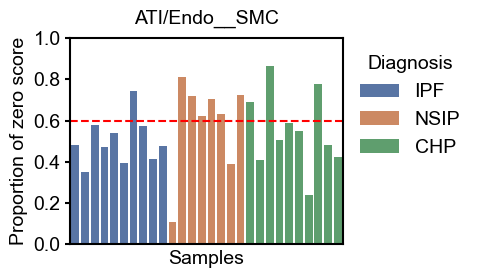

In [ ]:
target_interface = 'ATI/Endo__SMC'

# Filter for the specific interface
filtered_df = interface_df[(interface_df['interface'] == target_interface) & (interface_df['condition']!="UNC")]

# Ensure cond is categorical with the desired order
cond_order = ['IPF','NSIP','CHP']
filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)

# Sort the dataframe by cond to ensure correct order of bars
filtered_df = filtered_df.sort_values('condition')

# Create the barplot
plt.figure(figsize=(5, 3))
sns.barplot(
    data=filtered_df,
    x='library_id',
    y='zero_fraction',
    hue='condition',
    dodge=False,
    palette=sns.color_palette("deep")
)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

plt.title(f'{target_interface}', pad = 10)
plt.xlabel('Samples')
plt.ylabel('Proportion of zero score')

plt.ylim(0,1)
plt.xticks([])
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)

plt.legend(title='Diagnosis', bbox_to_anchor = (1, 1), frameon = False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,f"barplot_zero_frac_{target_interface.replace("/","").replace(". ","")}.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_28533/2315868009.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_28533/2315868009.py:16: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


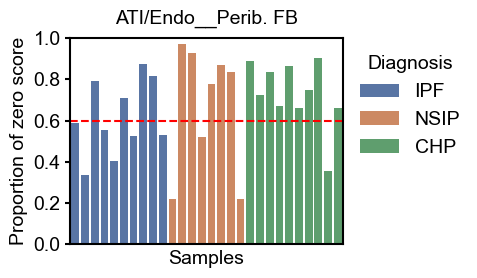

In [ ]:
target_interface = 'ATI/Endo__Perib. FB'

# Filter for the specific interface
filtered_df = interface_df[(interface_df['interface'] == target_interface) & (interface_df['condition']!="UNC")]

# Ensure cond is categorical with the desired order
cond_order = ['IPF','NSIP','CHP']
filtered_df['condition'] = pd.Categorical(filtered_df['condition'], categories=cond_order, ordered=True)

# Sort the dataframe by cond to ensure correct order of bars
filtered_df = filtered_df.sort_values('condition')

# Create the barplot
plt.figure(figsize=(5, 3))
sns.barplot(
    data=filtered_df,
    x='library_id',
    y='zero_fraction',
    hue='condition',
    dodge=False,
    palette=sns.color_palette("deep")
)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

plt.title(f'{target_interface}', pad =10)
plt.xlabel('Samples')
plt.ylabel('Proportion of zero score')

plt.ylim(0,1)
plt.xticks([])
#plt.legend(title = "Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)

plt.legend(title='Diagnosis', bbox_to_anchor = (1, 1), frameon = False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,f"barplot_zero_frac_{target_interface.replace("/","").replace(". ","")}.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

In [49]:
adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:].obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,factor_assigned,AT1/endo/immune,Airway,AbBa,SMC,FB,B/Plasma/immune,Macro,AT1/endo/immune__Airway,AT1/endo/immune__AbBa,AT1/endo/immune__SMC,AT1/endo/immune__AT2,AT1/endo/immune__FB,AT1/endo/immune__B/Plasma/immune,AT1/endo/immune__Macro,Airway__AbBa,Airway__SMC,Airway__AT2,Airway__FB,Airway__B/Plasma/immune,Airway__Macro,AbBa__SMC,AbBa__AT2,AbBa__FB,AbBa__B/Plasma/immune,AbBa__Macro,SMC__AT2,SMC__FB,SMC__B/Plasma/immune,SMC__Macro,AT2__FB,AT2__B/Plasma/immune,AT2__Macro,FB__B/Plasma/immune,FB__Macro,B/Plasma/immune__Macro
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,4803,8.477204,9582.0,9.167746,30.880818,33.928199,38.353162,47.088291,577.0,6.359574,6.021708,0.0,0.0,0.0,0.0,0.000000,0.000000,9582.0,4803,1,0.000061,0.000000,2.629412,0.006702,0.035119,0.000633,0.008993,0.386496,0.000275,0.000375,0.012340,0.005917,0.000067,0.000593,0.010685,0.001256,0.001317,0.181427,0.002944,0.108992,0.962809,0.000600,0.000545,0.017198,0.000150,0.000307,0.076197,0.004534,0.000030,0.003890,0.451629,B Cells,0.000000,0.000000,0.191632,0.068183,0.000000,0.315263,0.0,3.577525,0.000000,B/Plasma/immune,0.000000,0.000000,0.191632,0.068183,0.315263,3.577525,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016419,0.000000,0.046147,0.046147,0.000000,0.000000,0.016419,0.016419,0.000000,0.00000,0.0,0.000000,0.075919,0.000000,0.000000
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3942,8.279697,6462.0,8.773849,13.943052,18.415351,24.698236,37.062829,258.0,5.556828,3.992572,0.0,0.0,0.0,0.0,0.000000,0.000000,6462.0,3942,0,0.680275,0.352818,0.026757,0.013996,0.393806,0.083160,2.001077,0.321633,0.006606,0.011910,0.083977,0.005980,0.035921,0.252515,0.030069,0.028899,0.148690,0.638220,0.024814,0.012083,0.010404,0.009699,0.305559,0.126750,0.051342,0.269664,0.724418,0.049277,0.028364,0.059507,0.017307,Endothelial Cells,5.975328,1.167049,0.639472,0.984313,0.352818,0.294244,0.0,0.000000,0.269179,AT1/endo/immune,5.975328,1.167049,0.639472,0.984313,0.294244,0.000000,0.269179,0.120533,0.066045,0.101660,0.036439,0.030390,0.000000,0.027801,0.066045,0.101660,0.036439,0.030390,0.000000,0.027801,0.066045,0.036439,0.030390,0.000000,0.027801,0.036439,0.030390,0.000000,0.027801,0.03039,0.0,0.027801,0.000000,0.027801,0.000000
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12

In [58]:
interface_df

,library_id,condition,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
0,18_57617_A1,IPF,B__ATI/Endo,0.048055,0.136541,0.0,2.702400,5.941278,0.880507
1,18_57617_A1,IPF,B__Macro,0.025048,0.110111,0.0,4.501921,19.493202,0.945004
2,18_57617_A1,IPF,B__SMC,0.035611,0.122460,0.0,3.440790,10.823748,0.914195
3,18_57617_A1,IPF,B__Alv. FB/immune,0.060520,0.164883,0.0,2.616672,5.534464,0.868701
4,18_57617_A1,IPF,B__Plasma,0.040311,0.138604,0.0,3.416016,10.529263,0.914195
...,...,...,...,...,...,...,...,...,...
2899,22_16220_B1,IPF,Immune__Airway,0.110075,0.208924,0.0,1.489934,0.464101,0.770247
2900,22_16220_B1,IPF,Immune__ATII,0.271042,0.298076,0.0,0.314137,-1.700917,0.524852
2901,22_16220_B1,IPF,Alv. macro__Airway,0.054631,0.159476,0.0,2.761097,6.138303,0.887035
2902,22_16220_B1,IPF,Alv. macro__ATII,0.189138,0.286408,0.0,0.970051,-0.857297,0.679875


In [79]:
selected_interfaces = [
    "ATI/Endo__Alv. FB/immune",
    "ATI/Endo__SMC",
    "Alv. FB/immune__Immune",
    "ATI/Endo__Immune",
    "SMC__Alv. FB/immune",
    "ATI/Endo__ATII",
    "ATI/Endo__Perib. FB",
    "SMC__Immune",

    "Plasma__Alv. macro",
    "Immune__Alv. macro",
    "SMC__Airway"

]

condition_order = ["IPF", "NSIP", "CHP"]

df = (
    interface_df
    .loc[interface_df['condition'] !="UNC"]
    .loc[interface_df["interface"].isin(selected_interfaces)]
    .assign(
        condition=lambda x: pd.Categorical(
            x["condition"],
            categories=condition_order,
            ordered=True
        )
    )
)


In [80]:
df = df.sort_values(["condition", "library_id"])


In [81]:
df

,library_id,condition,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
12,18_57617_A1,IPF,ATI/Endo__SMC,0.270939,0.276783,0.247144,0.208591,-1.687229,0.480852
13,18_57617_A1,IPF,ATI/Endo__Alv. FB/immune,0.452240,0.281827,0.558944,-0.730413,-1.051437,0.248200
15,18_57617_A1,IPF,ATI/Endo__Perib. FB,0.223560,0.283744,0.000000,0.648446,-1.299119,0.589116
17,18_57617_A1,IPF,ATI/Endo__Immune,0.291320,0.279422,0.367549,0.067052,-1.741984,0.453498
20,18_57617_A1,IPF,ATI/Endo__ATII,0.165449,0.283097,0.000000,1.226647,-0.319947,0.732508
...,...,...,...,...,...,...,...,...,...
2410,24_27523_C5,CHP,SMC__Immune,0.213445,0.265574,0.000000,0.556209,-1.496716,0.587932
2412,24_27523_C5,CHP,SMC__Airway,0.078165,0.190301,0.000000,2.191514,3.194360,0.844248
2417,24_27523_C5,CHP,Alv. FB/immune__Immune,0.450092,0.295805,0.577598,-0.670928,-1.216523,0.276919
2424,24_27523_C5,CHP,Plasma__Alv. macro,0.108399,0.209982,0.000000,1.570225,0.769447,0.774099


In [ ]:
heatmap_df = df.pivot_table(
    index="interface",
    columns="library_id",
    values="zero_fraction",
    sort = False
).reindex(selected_interfaces)


In [484]:
heatmap_df

library_id,18_57617_A1,20_24241_A2,20_28197_A1,20_33940_B2,20_41501_C1,20_41615_B1,21_06301_B2,21_24095_A3,21_55747_C3,22_16220_B1,06_30914_A1,19_18542_A4,19_35057_C3,20_17688_B2,20_22642_A1,20_26330_B3,20_33362_C4,21_24837_A1,08_38774_B2,11_13888_A1,16_39724_B1,17_25789_B1,21_57231_A3,22_18440_A2,23_15209_A3,23_41922_B2,23_50343_B2,24_27523_C5
interface,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ATI/Endo__Alv. FB/immune,0.248200,0.323355,0.295830,0.157906,0.018379,0.309705,0.018268,0.096348,0.282294,0.397984,0.143554,0.111340,0.129436,0.094010,0.362249,0.101695,0.070678,0.229573,0.026796,0.106718,0.104563,0.020142,0.113383,0.084068,0.143883,0.221863,0.128120,0.195487
ATI/Endo__SMC,0.480852,0.474270,0.574089,0.413808,0.391923,0.541901,0.473701,0.352177,0.579710,0.741397,0.809851,0.107997,0.633264,0.388937,0.717999,0.621017,0.722063,0.703110,0.240000,0.588056,0.776806,0.548721,0.866165,0.410664,0.421884,0.691449,0.480588,0.505028
Alv. FB/immune__Immune,0.373164,0.511875,0.264359,0.359465,0.232203,0.494535,0.011024,0.345575,0.643037,0.502607,0.143111,0.796349,0.537462,0.398395,0.354903,0.310508,0.060809,0.817781,0.082718,0.336190,0.540684,0.228634,0.076692,0.236938,0.851809,0.367617,0.328064,0.276919
ATI/Endo__Immune,0.453498,0.444829,0.400210,0.292205,0.228061,0.522358,0.014173,0.336703,0.683680,0.342023,0.001553,0.802777,0.517049,0.432216,0.523312,0.288136,0.080548,0.783658,0.092427,0.271772,0.514068,0.215569,0.070977,0.239088,0.848937,0.220100,0.260122,0.237429
SMC__Alv. FB/immune,0.428160,0.436418,0.431943,0.422049,0.390888,0.444187,0.472126,0.352589,0.476371,0.773027,0.827380,0.061970,0.649501,0.332473,0.600170,0.608814,0.690863,0.766249,0.223301,0.607686,0.782510,0.552803,0.866466,0.381638,0.450029,0.721422,0.501387,0.572725
ATI/Endo__ATII,0.732508,0.570015,0.655389,0.447216,0.322288,0.561113,0.525669,0.543016,0.398551,0.289885,0.217661,0.626896,0.244259,0.433075,0.744561,0.200000,0.253741,0.134865,0.495534,0.142936,0.160837,0.452096,0.674286,0.355622,0.523550,0.596239,0.240710,0.260240
ATI/Endo__Perib. FB,0.589116,0.531667,0.875688,0.816258,0.709811,0.403776,0.554646,0.334434,0.792376,0.525895,0.970047,0.218822,0.870796,0.836629,0.927946,0.518644,0.218402,0.778552,0.748738,0.863699,0.904563,0.658410,0.836391,0.723500,0.662837,0.888628,0.356351,0.672553
SMC__Immune,0.557731,0.659080,0.575138,0.588641,0.537406,0.680689,0.474646,0.575820,0.797101,0.803962,0.809851,0.803806,0.797263,0.603898,0.756428,0.720678,0.714104,0.931755,0.287767,0.686204,0.901141,0.660044,0.862556,0.506988,0.897760,0.736115,0.604271,0.587932
Plasma__Alv. macro,0.945292,0.981692,0.905324,0.786860,0.953404,0.969526,0.937323,0.988034,0.921865,0.867223,0.489017,0.973258,0.951519,0.898252,0.947443,0.815593,0.893983,0.773909,0.986408,0.785458,0.906844,0.769461,0.894135,0.967319,0.974727,0.915957,0.974764,0.774099


In [485]:
import matplotlib.patches as patches


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2777425305.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2777425305.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2777425305.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2777425305.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykern

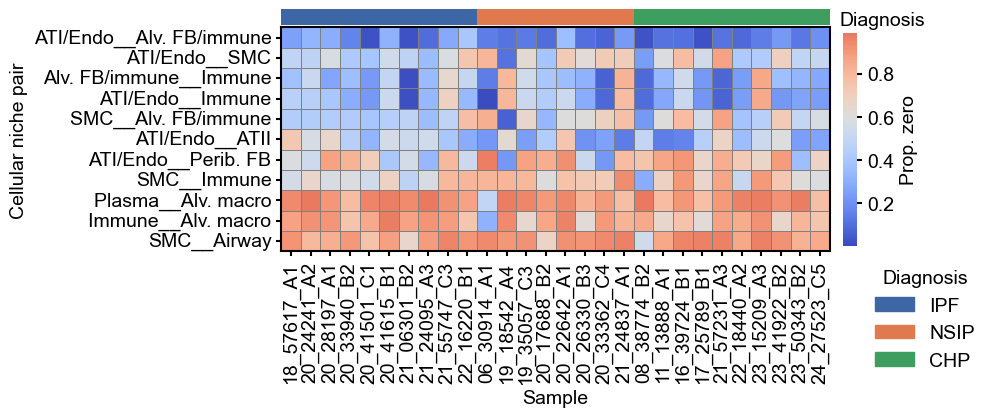

In [ ]:
#plt.figure(figsize=(0.5 * heatmap_df.shape[1], 0.5 * heatmap_df.shape[0]))
fig, ax = plt.subplots(figsize=(10, 4.5))
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}


sns.heatmap(
    heatmap_df,
    cmap="coolwarm",     
    center=0.6,          
    linewidths=0.5,
    linecolor='gray',
    ax= ax, 
    cbar_kws={"label": "Prop. zero", 'pad': 0.02, 'shrink': 0.95, 'aspect': 15}
)

# Determine condition for each library_id
col_colors = []
for lib_id in heatmap_df.columns:
    for cond in ['IPF','NSIP','CHP']:
        if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
            col_colors.append(cond_colors[cond])

# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")


# Add a color bar rectangle on top of each column
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
        width=1, height=0.8,  # height small to make a thin top bar
        facecolor=color,
        transform=ax.transData,
        
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)
ax.text(
    x=len(heatmap_df.columns) + 0.5,  # slightly right of last column
    y=-0.35,                           # vertical position, aligned with top bar
    s="Diagnosis", 
    fontsize=14, zorder = 2,
    #fontweight="bold",
    va="center"  # vertical alignment
)
# Optionally, add a legend for the conditions
handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

plt.xlabel("Sample")
plt.ylabel("Cellular niche pair")
plt.title("")

plt.tight_layout()
plt.show()


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2241489652.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2241489652.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2241489652.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/2241489652.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykern

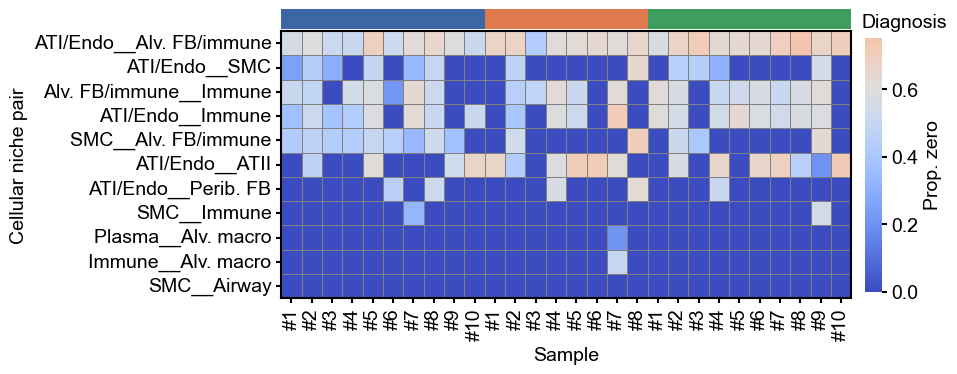

In [ ]:
#plt.figure(figsize=(0.5 * heatmap_df.shape[1], 0.5 * heatmap_df.shape[0]))
fig, ax = plt.subplots(figsize=(10, 4))
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}

# Create new df, first sorted by condition then by replicate
heatmap_df_resorted = (heatmap_df.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        heatmap_df.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
heatmap_df_resorted.columns = "#" + heatmap_df_resorted.columns.str.split('#',n = 1, expand = False).str[-1]

sns.heatmap(
    heatmap_df_resorted,
    cmap="coolwarm",       
    center=0.6,          
    linewidths=0.5,
    linecolor='gray',
    ax= ax,
    cbar_kws={"label": "Prop. zero", 'pad': 0.02, 'shrink': 0.95, 'aspect': 15}
)

# Determine condition for each library_id
col_colors = []
for lib_id in heatmap_df.columns:
    for cond in ['IPF','NSIP','CHP']:
        if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
            col_colors.append(cond_colors[cond])

# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")


# Add a color bar rectangle on top of each column
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
        width=1, height=0.8,  # height small to make a thin top bar
        facecolor=color,
        transform=ax.transData,
        
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)
ax.text(
    x=len(heatmap_df.columns) + 0.5,  # slightly right of last column
    y=-0.35,                           # vertical position, aligned with top bar
    s="Diagnosis", 
    fontsize=14, zorder = 2,
    #fontweight="bold",
    va="center"  # vertical alignment
)
# Optionally, add a legend for the conditions
# handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
# ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

plt.xlabel("Sample")
plt.ylabel("Cellular niche pair")
plt.title("")

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_interfaces_samples_prop_zero.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


In [373]:
df

,library_id,condition,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
12,18_57617_A1,IPF,ATI/Endo__SMC,0.270939,0.276783,0.247144,0.208591,-1.687229,0.480852
13,18_57617_A1,IPF,ATI/Endo__Alv. FB/immune,0.452240,0.281827,0.558944,-0.730413,-1.051437,0.248200
15,18_57617_A1,IPF,ATI/Endo__Perib. FB,0.223560,0.283744,0.000000,0.648446,-1.299119,0.589116
17,18_57617_A1,IPF,ATI/Endo__Immune,0.291320,0.279422,0.367549,0.067052,-1.741984,0.453498
20,18_57617_A1,IPF,ATI/Endo__ATII,0.165449,0.283097,0.000000,1.226647,-0.319947,0.732508
...,...,...,...,...,...,...,...,...,...
2410,24_27523_C5,CHP,SMC__Immune,0.213445,0.265574,0.000000,0.556209,-1.496716,0.587932
2412,24_27523_C5,CHP,SMC__Airway,0.078165,0.190301,0.000000,2.191514,3.194360,0.844248
2417,24_27523_C5,CHP,Alv. FB/immune__Immune,0.450092,0.295805,0.577598,-0.670928,-1.216523,0.276919
2424,24_27523_C5,CHP,Plasma__Alv. macro,0.108399,0.209982,0.000000,1.570225,0.769447,0.774099


In [499]:
heatmap_df = df.pivot_table(
    index="interface",
    columns="library_id",
    values="median_score",
    sort = False
).reindex(selected_interfaces)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/1788504466.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/1788504466.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/1788504466.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_35321/1788504466.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykern

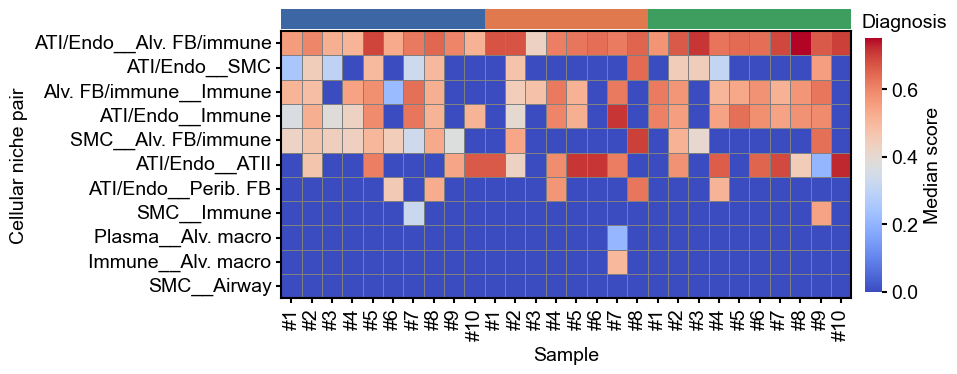

In [ ]:
#plt.figure(figsize=(0.5 * heatmap_df.shape[1], 0.5 * heatmap_df.shape[0]))
fig, ax = plt.subplots(figsize=(10, 4))
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}

# Create new df, first sorted by condition then by replicate
heatmap_df_resorted = (heatmap_df.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        heatmap_df.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
heatmap_df_resorted.columns = "#" + heatmap_df_resorted.columns.str.split('#',n = 1, expand = False).str[-1]

sns.heatmap(
    heatmap_df_resorted,
    cmap="coolwarm",       
    #center=0.6,          
    linewidths=0.5,
    linecolor='gray',
    ax= ax,
    cbar_kws={"label": "Median score", 'pad': 0.02, 'shrink': 0.95, 'aspect': 15}
)

# Determine condition for each library_id
col_colors = []
for lib_id in heatmap_df.columns:
    for cond in ['IPF','NSIP','CHP']:
        if lib_id in df[interface_df['condition'] == cond]['library_id'].unique():
            col_colors.append(cond_colors[cond])

# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")


# Add a color bar rectangle on top of each column
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
        width=1, height=0.8,  # height small to make a thin top bar
        facecolor=color,
        transform=ax.transData,
        
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)
ax.text(
    x=len(heatmap_df.columns) + 0.5,  # slightly right of last column
    y=-0.35,                           # vertical position, aligned with top bar
    s="Diagnosis", 
    fontsize=14, zorder = 2,
    #fontweight="bold",
    va="center"  # vertical alignment
)
# Optionally, add a legend for the conditions
# handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
# ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

plt.xlabel("Sample")
plt.ylabel("Cellular niche pair")
plt.title("")

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_interfaces_samples_median.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()
